In [17]:
# Importing numpy and matplotlib
import numpy as np 
import matplotlib.pyplot as plt

# Please provide the name of your output file from the poisson program

In [18]:
filename = "results.dat"

In [19]:
# Load Data

all_data = np.loadtxt(filename,skiprows=3)
all_data = all_data.transpose()

x = all_data[0]
y = all_data[1]
phi = all_data[2]

In [20]:
# Manipulate data into formats that work better for the plots we wish to do

dim_len = int(np.sqrt(phi.size))
    
x_list = x[0:x.size:dim_len]
y_list = y[0:dim_len]

phi_matrix = np.zeros((dim_len,dim_len))

for n in range(0,dim_len):
    for m in range(0,dim_len):
        phi_matrix[m,n] = phi[n*dim_len+m]
        #every m is a different y value (different row), every n is a different x value (different column)

x3d, y3d = np.meshgrid(x_list, y_list)

# Colormap Representation

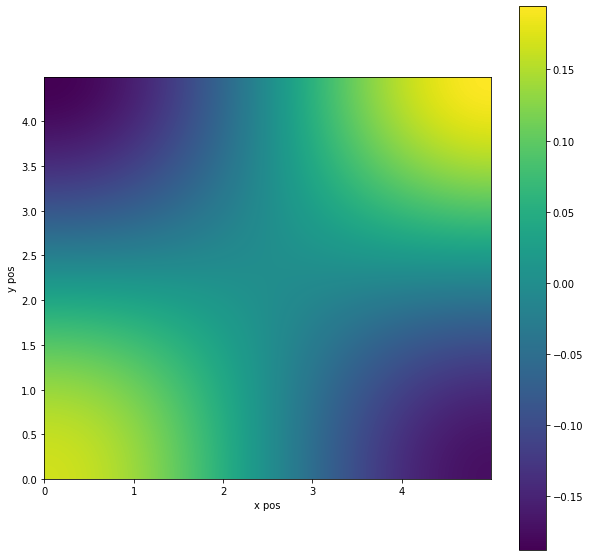

In [21]:
%matplotlib inline

fig, ax = plt.subplots(1,1)        
img = ax.imshow(phi_matrix, origin = 'lower', extent = (min(x),max(x),min(y),max(y)))

ax.set_xlabel("x pos")
ax.set_ylabel("y pos")

fig.set_figheight(10)
fig.set_figwidth(10)
fig.colorbar(img)
fig.show()

# Contour representation

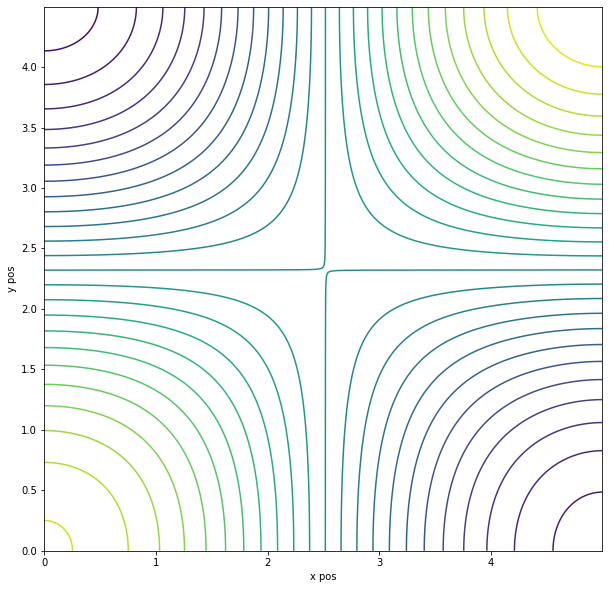

In [22]:
%matplotlib inline

fig, ax = plt.subplots(1,1)        

ax.contour(x3d, y3d, phi_matrix,25)
ax.set_xlabel("x pos")
ax.set_ylabel("y pos")

fig.set_figheight(10)
fig.set_figwidth(10)
fig.show()

# 3D Plot representation

In [23]:
# 3-D plot for better visualization
%matplotlib notebook
from mpl_toolkits.mplot3d import axes3d
from matplotlib import cm
from matplotlib.ticker import LinearLocator


fig = plt.figure(figsize = (8,5))
ax = plt.axes(projection='3d')

ax.plot_surface(x3d, y3d, phi_matrix, cmap=cm.coolwarm,
                       linewidth=0, antialiased=True)

# Set appropriate labels with the correct units.
ax.set_xlabel("x pos", fontsize = 12)
ax.set_ylabel("y pos", fontsize = 12)
ax.set_zlabel("phi", fontsize = 12)
fig.set_figheight(10)
fig.set_figwidth(10)
fig.show()

<IPython.core.display.Javascript object>

# Gradient Vector Field

### Useful for checking if (Neumann) boundary conditions are accurately held

There are  34  by  34  =  1156  vectors


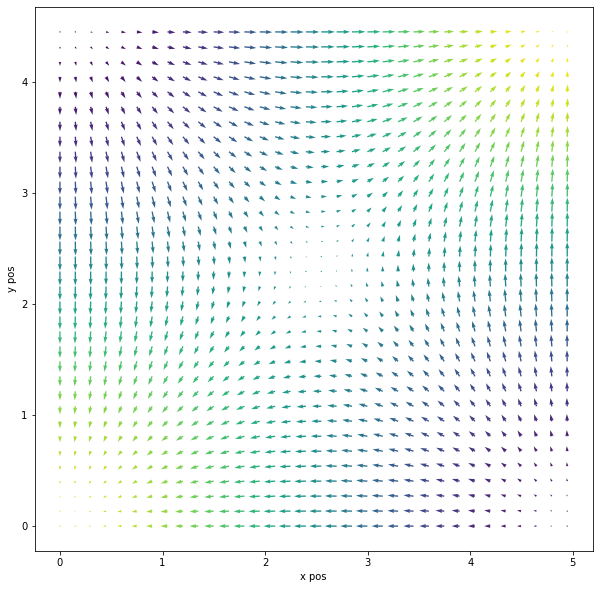

In [24]:
%matplotlib inline

dx = x_list[1]-x_list[0]
dy = y_list[1]-y_list[0]

u = np.zeros((dim_len,dim_len))
v = np.zeros((dim_len,dim_len))

for n in range(0,dim_len):
    for m in range(0,dim_len):
        a = 0.0
        b = 0.0
        c = 0.0
        d = 0.0
        
        if(0<m and m<dim_len-1):
            a = phi_matrix[n,m+1]
            b = phi_matrix[n,m-1]
        else:
            if(m==0):
                a = 2*phi_matrix[n,m+1]
                b = 2*phi_matrix[n,m]
            elif(m==dim_len-1):
                a = 2*phi_matrix[n,m]
                b = 2*phi_matrix[n,m-1]

        if(0<n and n<dim_len-1):
            c = phi_matrix[n+1,m]
            d = phi_matrix[n-1,m]
        else:
            if(n==0):
                c = 2*phi_matrix[n+1,m]
                d = 2*phi_matrix[n,m]
            elif(n==dim_len-1):
                c = 2*phi_matrix[n,m]
                d = 2*phi_matrix[n-1,m]
        
        # Remember, first index of phi_matrix is y values, second index is x values
        # u is x compnent of the gradient
        u[n,m] = (a-b)/(2*dx)
        # v is y compnent of the gradient
        v[n,m] = (c-d)/(2*dy)


skip=30
vecs_order = x3d[::skip,::skip].shape
print("There are ", vecs_order[0]," by ", vecs_order[1], " = ", x3d[::skip,::skip].size ," vectors")

fig, ax = plt.subplots(1,1) 
ax.quiver(x3d[::skip,::skip],y3d[::skip,::skip],u[::skip,::skip],v[::skip,::skip], phi_matrix[::skip,::skip])
ax.set_xlabel("x pos")
ax.set_ylabel("y pos")

fig.set_figheight(10)
fig.set_figwidth(10)

fig.show()